# PW03 - Classification with Bayes - System Evaluation

**Team:** Noé Berdoz, Michael Strefeler

## Preamble: our starting level

- **Noé Berdoz**: Bachelor in Business Information Technology (Informatique de gestion) at HE-Arc, completed in 2026. Background in software development, with little prior experience in machine learning before this course.
- **Michael Strefeler**: Bachelor in Computer and Communication Systems (ISC) at HEIG-VD, completed in 2025, with a specialisation in data science, so he had already seen some machine learning before this course.

We spent about 6 hours in total on the 3 exercises of this PW.
For exercise 1, we worked about 2 hours.

## Bonus request

We would like to apply for this bonus because we did a bit more than what was asked.

Here is what we have done in this notebook:

We compared histogram and Gaussian likelihoods and examined how zero-likelihood ties affect accuracy.


## Exercise 1 - Bayes classification system

In [1]:
# Import some useful libraries

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## 1a. Getting started with Bayes

a) Read the training data from file ex1-data-train.csv. The first two columns are x1 and x2. The last column holds the class label y.

In [2]:
def read_data(file):
    dataset = pd.read_csv(file, names=['x1','x2','y'])
    print(dataset.head())
    return dataset[["x1", "x2"]], dataset["y"].values

In [3]:
X_train, y_train = read_data("ex1-data-train.csv")

          x1         x2  y
0  34.623660  78.024693  0
1  30.286711  43.894998  0
2  35.847409  72.902198  0
3  60.182599  86.308552  1
4  79.032736  75.344376  1


In [4]:
# Prepare a function to compute accuracy
def accuracy_score(y_true, y_pred):
    return (y_true == y_pred).sum() / y_true.size

b) Compute the priors of both classes P(C0) and P(C1)

In [5]:
# TODO: Compute the priors

n_c0 = np.sum(y_train == 0)
n_c1 = np.sum(y_train == 1)

prior_c0 = n_c0 / len(y_train)
prior_c1 = n_c1 / len(y_train)

print("N0 =", n_c0, "N1 =", n_c1)
print("P(C0) =", prior_c0, "P(C1) =", prior_c1)

N0 = 40 N1 = 60
P(C0) = 0.4 P(C1) = 0.6


c) Compute histograms of x1 and x2 for each class (total of 4 histograms). Plot these histograms. Advice : use the numpy `histogram(a, bins="auto")` function.

x1 | C0: 7 bins, counts [12  5 11  5  3  2  2]
x1 | C1: 7 bins, counts [ 3  5  9  9 16  9  9]
x2 | C0: 7 bins, counts [ 5 16  6  5  6  0  2]
x2 | C1: 7 bins, counts [ 8  3  7 12  8 12 10]


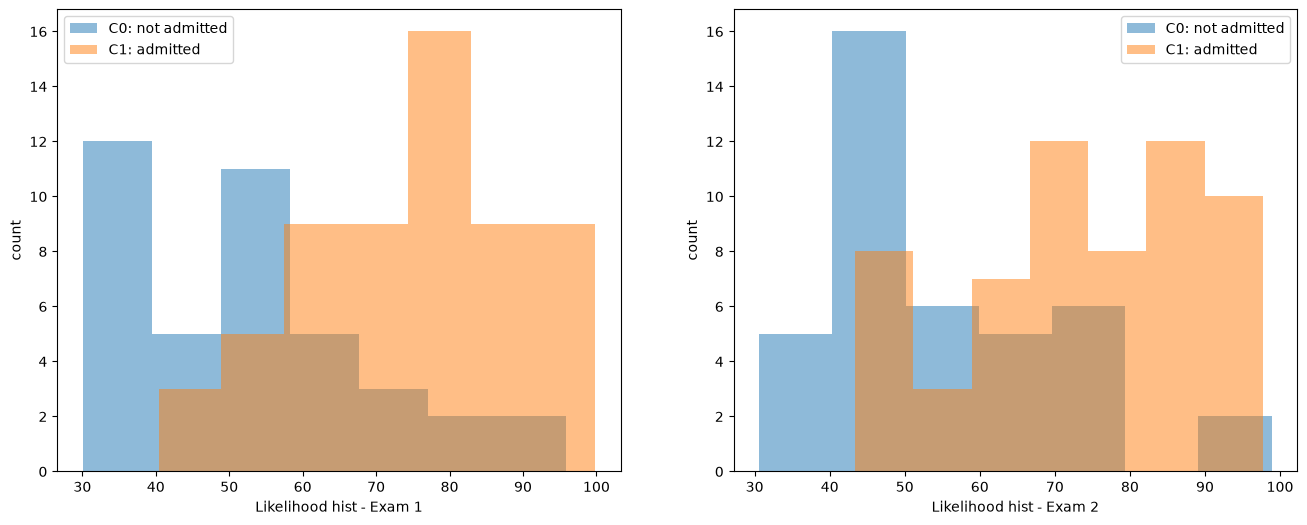

In [6]:
# TODO: Compute histograms

x1_c0 = X_train["x1"][y_train == 0]
x1_c1 = X_train["x1"][y_train == 1]
x2_c0 = X_train["x2"][y_train == 0]
x2_c1 = X_train["x2"][y_train == 1]

hist_x1_c0, edges_x1_c0 = np.histogram(x1_c0, bins="auto")
hist_x1_c1, edges_x1_c1 = np.histogram(x1_c1, bins="auto")
hist_x2_c0, edges_x2_c0 = np.histogram(x2_c0, bins="auto")
hist_x2_c1, edges_x2_c1 = np.histogram(x2_c1, bins="auto")

print("x1 | C0:", len(hist_x1_c0), "bins, counts", hist_x1_c0)
print("x1 | C1:", len(hist_x1_c1), "bins, counts", hist_x1_c1)
print("x2 | C0:", len(hist_x2_c0), "bins, counts", hist_x2_c0)
print("x2 | C1:", len(hist_x2_c1), "bins, counts", hist_x2_c1)

# TODO: plot histograms

plt.figure(figsize=(16,6))

plt.subplot(1, 2, 1)

plt.stairs(hist_x1_c0, edges_x1_c0, fill=True, alpha=0.5, label="C0: not admitted")
plt.stairs(hist_x1_c1, edges_x1_c1, fill=True, alpha=0.5, label="C1: admitted")
plt.ylabel("count")
plt.legend()

plt.xlabel('Likelihood hist - Exam 1')

plt.subplot(1, 2, 2)

plt.stairs(hist_x2_c0, edges_x2_c0, fill=True, alpha=0.5, label="C0: not admitted")
plt.stairs(hist_x2_c1, edges_x2_c1, fill=True, alpha=0.5, label="C1: admitted")
plt.ylabel("count")
plt.legend()

plt.xlabel('Likelihood hist - Exam 2')

plt.show()

d) Use the histograms to compute the likelihoods p(x1|C0), p(x1|C1), p(x2|C0) and p(x2|C1). For this define a function `likelihood_hist(x, hist_values, edge_values)` that returns the likelihood of x for a given histogram (defined by its values and bin edges as returned by the numpy `histogram()` function).

In [7]:
def likelihood_hist(x: float, hist_values: np.ndarray, bin_edges: np.ndarray) -> float:
    # TODO: compute likelihoods from histograms outputs

    # outside the histogram the likelihood is 0 as no training points are present.
    if x < bin_edges[0] or x > bin_edges[-1]:
        return 0.0

    for i in range(len(hist_values)):
        if x < bin_edges[i + 1] or i == len(hist_values) - 1:
            # density = share of the training points in this bin, divided by the bin width
            width = bin_edges[i + 1] - bin_edges[i]
            return hist_values[i] / (np.sum(hist_values) * width)

# a quick check on one score: exam 1 = 50
print("p(x1=50 | C0) =", likelihood_hist(50, hist_x1_c0, edges_x1_c0))
print("p(x1=50 | C1) =", likelihood_hist(50, hist_x1_c1, edges_x1_c1))
print("p(x1=25 | C0) =", likelihood_hist(25, hist_x1_c0, edges_x1_c0))

# the same densities straight from NumPy, to compare
density_x1_c0, edges_check = np.histogram(x1_c0, bins="auto", density=True)
print(density_x1_c0)


p(x1=50 | C0) = 0.029254104248110622
p(x1=50 | C1) = 0.00982533802914316
p(x1=25 | C0) = 0.0
[0.03191357 0.01329732 0.0292541  0.01329732 0.00797839 0.00531893
 0.00531893]


e) Implement the classification decision according to Bayes rule and compute the overall accuracy of the system on the test set ex1-data-test.csv. :
- using only feature x1
- using only feature x2
- using x1 and x2 making the naive Bayes hypothesis of feature independence, i.e. p(X|Ck) = p(x1|Ck) · p(x2|Ck)

In [8]:
X_test, y_test = read_data("ex1-data-test.csv")

          x1         x2  y
0  39.196334  78.530294  0
1  40.448499  86.839470  1
2  65.571920  44.303497  0
3  79.648113  70.806564  1
4  66.260221  41.672703  0


In [9]:
# TODO: predict on test set in the 3 cases described above

# case 1: only feature x1
y_pred = []

for i in range(len(X_test)):
    x1 = X_test["x1"][i]
    score_c0 = likelihood_hist(x1, hist_x1_c0, edges_x1_c0) * prior_c0 # p(x1|C0) P(C0)
    score_c1 = likelihood_hist(x1, hist_x1_c1, edges_x1_c1) * prior_c1 # p(x1|C1) P(C1)
    if score_c1 > score_c0:
        y_pred.append(1)
    else:
        y_pred.append(0) # C0 also wins a tie

accuracy_score(y_test, y_pred)

np.float64(0.7)

In [10]:
# case 2: only feature x2
y_pred = []

for i in range(len(X_test)):
    x2 = X_test["x2"][i]
    score_c0 = likelihood_hist(x2, hist_x2_c0, edges_x2_c0) * prior_c0  # p(x2|C0) P(C0)
    score_c1 = likelihood_hist(x2, hist_x2_c1, edges_x2_c1) * prior_c1  # p(x2|C1) P(C1)
    if score_c1 > score_c0:
        y_pred.append(1)
    else:
        y_pred.append(0)

accuracy_score(y_test, y_pred)

np.float64(0.73)

In [11]:
# case 3: x1 and x2, naive Bayes: p(x|Ck) = p(x1|Ck) * p(x2|Ck)
y_pred = []

for i in range(len(X_test)):
    x1 = X_test["x1"][i]
    x2 = X_test["x2"][i]
    score_c0 = likelihood_hist(x1, hist_x1_c0, edges_x1_c0) * likelihood_hist(x2, hist_x2_c0, edges_x2_c0) * prior_c0
    score_c1 = likelihood_hist(x1, hist_x1_c1, edges_x1_c1) * likelihood_hist(x2, hist_x2_c1, edges_x2_c1) * prior_c1
    if score_c1 > score_c0:
        y_pred.append(1)
    else:
        y_pred.append(0)

accuracy_score(y_test, y_pred)

np.float64(0.92)

Which system is the best ?

The naive Bayes system that uses both exams is the best with an accuracy of 0.92 on the test set.

With exam 1 only, the accuracy is 0.70, and with exam 2 only, it is 0.73. One exam alone cannot separate the classes well, because admitted and refused students overlap a lot on each axis. The admission depends on both scores together, and the border in the scatter plot is diagonal. Combining the two likelihoods gives the classifier this information.

But two limits apply. The test set holds only 100 students. There are 9 ties where both classes got a likelihood of 0 and the code chose C0. Of these 9 students, 7 are correctly classified as C0 and 2 are misclassified. If we change the condition with `>=` rather than `>`, then the same 9 students would go to C1 and the score would be 87 %.

## 1b. Bayes - Univariate Gaussian distribution

Do the same as in a) but this time using univariate Gaussian distribution to model the likelihoods p(x1|C0), p(x1|C1), p(x2|C0) and p(x2|C1). You may use the numpy functions `mean()` and `var()` to compute the mean μ and variance σ2 of the distribution. To model the likelihood of both features, you may also do the naive Bayes hypothesis of feature independence, i.e. p(X|Ck) = p(x1|Ck) · p(x2|Ck).


In [12]:
def likelihood_univariate_gaussian(x: float, mean: float, var: float) -> float:
    # TODO: compute likelihoods from histograms outputs

    # Gaussian probability density function
    return 1 / math.sqrt(2 * math.pi * var) * math.exp(-(x - mean) ** 2 / (2 * var))

x1 | C0: mean 52.03  var 300.27
x1 | C1: mean 74.72  var 218.67
x2 | C0: mean 54.62  var 252.15
x2 | C1: mean 73.96  var 252.12


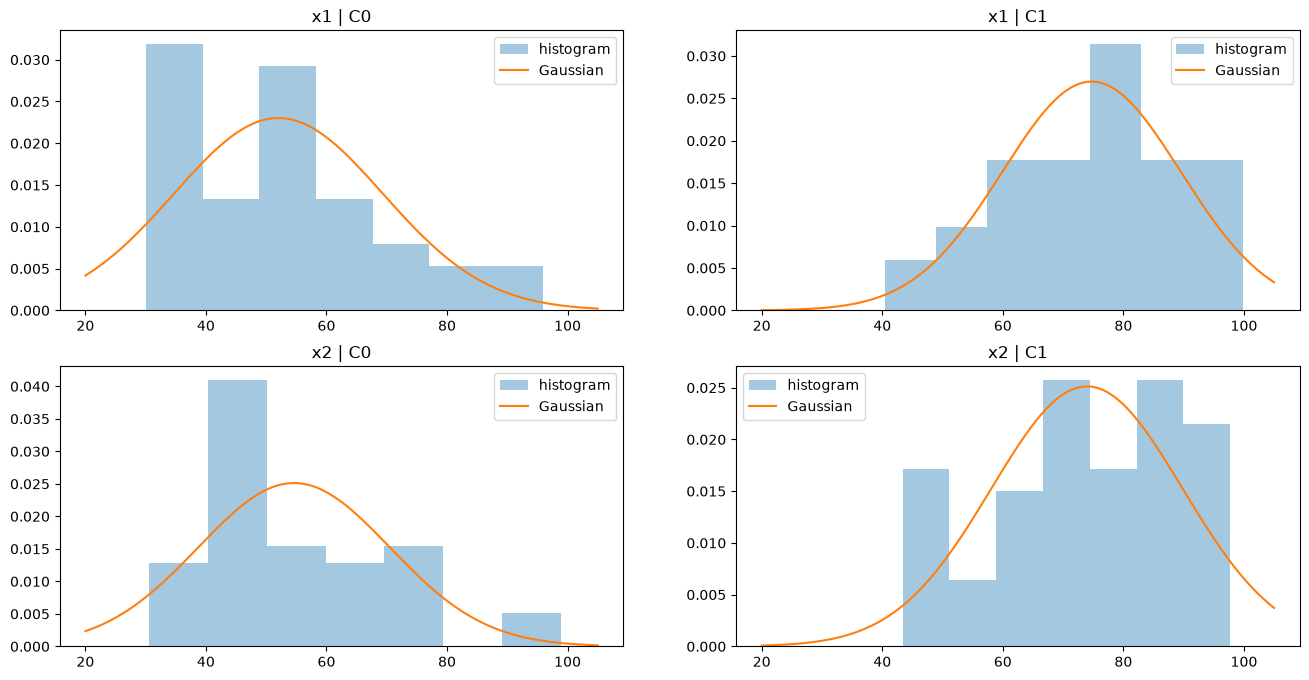

In [13]:
# TODO: Compute mean and variance for each classes and each features (8 values)

mean_x1_c0 = np.mean(x1_c0)
var_x1_c0 = np.var(x1_c0)
mean_x1_c1 = np.mean(x1_c1)
var_x1_c1 = np.var(x1_c1)
mean_x2_c0 = np.mean(x2_c0)
var_x2_c0 = np.var(x2_c0)
mean_x2_c1 = np.mean(x2_c1)
var_x2_c1 = np.var(x2_c1)

print("x1 | C0: mean", round(mean_x1_c0, 2), " var", round(var_x1_c0, 2))
print("x1 | C1: mean", round(mean_x1_c1, 2), " var", round(var_x1_c1, 2))
print("x2 | C0: mean", round(mean_x2_c0, 2), " var", round(var_x2_c0, 2))
print("x2 | C1: mean", round(mean_x2_c1, 2), " var", round(var_x2_c1, 2))

# histogram (as a density) and Gaussian, on the same axes
x_axis = np.linspace(20, 105, 300)  # 300 scores between 20 and 105, to draw smooth curves

features = [x1_c0, x1_c1, x2_c0, x2_c1]
means = [mean_x1_c0, mean_x1_c1, mean_x2_c0, mean_x2_c1]
variances = [var_x1_c0, var_x1_c1, var_x2_c0, var_x2_c1]
titles = ["x1 | C0", "x1 | C1", "x2 | C0", "x2 | C1"]

plt.figure(figsize=(16,8))

for n in range(4):
    plt.subplot(2, 2, n + 1)
    # density=True gives the same values as likelihood_hist
    density, edges = np.histogram(features[n], bins="auto", density=True)
    plt.stairs(density, edges, fill=True, alpha=0.4, label="histogram")
    curve = []
    for x in x_axis:
        curve.append(likelihood_univariate_gaussian(x, means[n], variances[n]))
    plt.plot(x_axis, curve, label="Gaussian")
    plt.title(titles[n])
    plt.legend()

plt.show()

In [14]:
# TODO: predict on test set in the 3 cases

# case 1: only feature x1
y_pred = []

for i in range(len(X_test)):
    x1 = X_test["x1"][i]
    score_c0 = likelihood_univariate_gaussian(x1, mean_x1_c0, var_x1_c0) * prior_c0
    score_c1 = likelihood_univariate_gaussian(x1, mean_x1_c1, var_x1_c1) * prior_c1
    if score_c1 > score_c0:
        y_pred.append(1)
    else:
        y_pred.append(0)

accuracy_score(y_test, y_pred)

np.float64(0.71)

In [15]:
# case 2: only feature x2
y_pred = []

for i in range(len(X_test)):
    x2 = X_test["x2"][i]
    score_c0 = likelihood_univariate_gaussian(x2, mean_x2_c0, var_x2_c0) * prior_c0
    score_c1 = likelihood_univariate_gaussian(x2, mean_x2_c1, var_x2_c1) * prior_c1
    if score_c1 > score_c0:
        y_pred.append(1)
    else:
        y_pred.append(0)

accuracy_score(y_test, y_pred)

np.float64(0.72)

In [16]:
# case 3: x1 and x2, naive Bayes
y_pred = []

for i in range(len(X_test)):
    x1 = X_test["x1"][i]
    x2 = X_test["x2"][i]
    score_c0 = likelihood_univariate_gaussian(x1, mean_x1_c0, var_x1_c0) * likelihood_univariate_gaussian(x2, mean_x2_c0, var_x2_c0) * prior_c0
    score_c1 = likelihood_univariate_gaussian(x1, mean_x1_c1, var_x1_c1) * likelihood_univariate_gaussian(x2, mean_x2_c1, var_x2_c1) * prior_c1
    if score_c1 > score_c0:
        y_pred.append(1)
    else:
        y_pred.append(0)

accuracy_score(y_test, y_pred)

np.float64(0.89)

| System | Histogram | Gaussian |
|---|---|---|
| x1 only | 0.70 | 0.71 |
| x2 only | 0.73 | 0.72 |
| x1 + x2, naive Bayes | 0.92 | 0.89 |

With univariate Gaussian likelihoods, the accuracy is 0.71 with x1 only, 0.72 with x2 only, and 0.89 with naive Bayes on both features. As with histograms, the naive Bayes system with both features is the best.

It is three test students behind the histogram version (0.92), but the Gaussian is smooth and never exactly 0, so it avoids the ties and the hard zeros of the histogram, but it cannot follow a shape that is not a bell, such as the exam 1 scores of the refused students.

On a test set of 100 students, the difference of 0.03 is too small to prefer one estimator in general.